CAT-DOG CLASSIFICATION

In [185]:
# Standard library
import copy
import glob
import multiprocessing
import os
import time
import zipfile

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torch.nn.utils.prune as prune

# Related third party
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

In [186]:
print(torch.__version__)

2.12.0+cpu


In [187]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [188]:
def print_model_size(mdl):
    torch.save(mdl.state_dict(), "tmp.pt")
    print("%.2f MB" %(os.path.getsize("tmp.pt")/1e6))
    os.remove('tmp.pt')

In [189]:
input_size = (224,224)
mean = [0.485, 0.456, 0.406] 
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize(input_size),  # Resize to a fixed size
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [190]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label, folder_name in enumerate(['Dog', 'Cat']):
            folder_path = os.path.join(self.root_dir, folder_name)
            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file_name)
                
                try:
                    with Image.open(file_path) as img:
                        
                        if img.mode != 'RGB':
                            img = img.convert('RGB')
                        
                        if img.mode != 'RGB':
                            print(f"Skipping {file_path} because it does not have 3 channels (RGB)")
                            continue

                        self.image_paths.append(file_path)
                        self.labels.append(label)
                        
                except Exception as e:
                    print(f"Skipping {file_path} due to error: {e}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        with Image.open(image_path) as img:

            if img.mode != 'RGB':
                img = img.convert('RGB')

            if self.transform:
                img = self.transform(img)
            
        return img, label

In [191]:
dataset = CustomDataset(root_dir='../data/PetImages', transform=transform)

# Calculate split sizes
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split dataset into train and test
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

Skipping ../data/PetImages\Dog\11702.jpg due to error: cannot identify image file '../data/PetImages\\Dog\\11702.jpg'
Skipping ../data/PetImages\Dog\Thumbs.db due to error: cannot identify image file '../data/PetImages\\Dog\\Thumbs.db'
Skipping ../data/PetImages\Cat\666.jpg due to error: cannot identify image file '../data/PetImages\\Cat\\666.jpg'
Skipping ../data/PetImages\Cat\Thumbs.db due to error: cannot identify image file '../data/PetImages\\Cat\\Thumbs.db'


In [192]:
# Create DataLoader for train and test sets
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([128, 3, 224, 224])
torch.Size([128])


In [193]:
def train_epoch(model, criterion, optimizer, data_loader, device,epoch):
    model.train()
    
    epoch_loss = 0.0
    num_batches = len(data_loader)
    
    for batch_idx, (image, target) in enumerate(tqdm(data_loader)):
        image, target = image.to(device), target.to(device)
        
        output = model(image)
        
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    print(f"Epoch = {epoch+1} || Training Loss: {avg_epoch_loss:.4f}")


def evaluate(model, criterion, data_loader, device,epoch):
    
    model.eval()
    
    epoch_loss = 0.0
    
    correct_predictions = 0
    total_predictions = 0
    
    num_batches = len(data_loader)
    
    with torch.no_grad():
       
        for image, target in tqdm(data_loader):
            image, target = image.to(device), target.to(device)
            output = model(image)
            loss = criterion(output, target)
            # Accumulate batch loss
            epoch_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(output, 1)  # Get the predicted class index
            correct_predictions += (predicted == target).sum().item()
            total_predictions += target.size(0)
            
    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    accuracy = correct_predictions / total_predictions
    
    print(f"Epoch = {epoch+1} || Validation Loss: {avg_epoch_loss:.4f} || Validation Accuracy: {accuracy:.4f}")
    return accuracy*100

# calculate sensitivity of each layer
def measure_layer_sensitivity(model, layer_name, test_loader, device, criterion, epoch):
    temp_model = copy.deepcopy(model)
    temp_model.to(device)
    temp_model.eval()

    # find the layer
    module = dict(temp_model.named_modules())[layer_name]

    # prune 10% of filters
    prune.ln_structured(module, name="weight", amount=0.5, n=1, dim=0)
    prune.remove(module, "weight")

    # evaluate accuracy
    acc = evaluate(temp_model, criterion, test_loader, device, epoch)

    return acc


In [194]:
class MobileNet(torch.nn.Module):
    def __init__(self):
        super(MobileNet, self).__init__()
        self.model = models.mobilenet_v2(weights=None)  
        
        # for param in self.model.parameters():
        #     param.requires_grad = False
            
        
        
        self.model.classifier[1] = nn.Sequential(
            nn.Linear(in_features=self.model.classifier[1].in_features,out_features=512),
            nn.LeakyReLU(negative_slope=0.02,inplace=False),
            nn.BatchNorm1d(num_features=512),
            nn.Dropout(p=0.4,inplace=False),
            nn.Linear(in_features=512,out_features=2),
            nn.Softmax(dim=1))
        
        # print(self.model)

    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
model = MobileNet()
model.load_state_dict(torch.load("../model/original_catndog_mobilenetv2.pth"))
PrunningModel = copy.deepcopy(model)
print_model_size(PrunningModel)

<All keys matched successfully>

In [ ]:
# Training Setting
num_epochs = 15
PrunningModel = PrunningModel.to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.Adam(PrunningModel.parameters(), lr = 1e-4)
originalModel_acc = evaluate(PrunningModel, criterion, test_loader, device, epoch=0)

100%|██████████| 40/40 [01:17<00:00,  1.95s/it]

Epoch = 1 || Validation Loss: 0.3159 || Validation Accuracy: 0.9972


In [ ]:
sensitivities = {}
for name, module in PrunningModel.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(f"Estimate sensitivity of layer: {name}")
        acc = measure_layer_sensitivity(model, name, test_loader, device, criterion=criterion, epoch=0)
        print(f"Validation Accuracy: {acc:.2f}%")
        sensitivities[name] = acc

Estimate sensitivity of layer: model.features.0.0


100%|██████████| 40/40 [01:34<00:00,  2.35s/it]


Epoch = 1 || Validation Loss: 0.3480 || Validation Accuracy: 0.9632
Validation Accuracy: 96.32%
Estimate sensitivity of layer: model.features.1.conv.0.0


100%|██████████| 40/40 [01:30<00:00,  2.27s/it]


Epoch = 1 || Validation Loss: 0.7421 || Validation Accuracy: 0.5412
Validation Accuracy: 54.12%
Estimate sensitivity of layer: model.features.1.conv.1


...

Epoch = 1 || Validation Loss: 0.3172 || Validation Accuracy: 0.9970
Validation Accuracy: 99.70%
Estimate sensitivity of layer: model.features.17.conv.2


100%|██████████| 40/40 [01:22<00:00,  2.07s/it]


Epoch = 1 || Validation Loss: 0.3852 || Validation Accuracy: 0.9326
Validation Accuracy: 93.26%
Estimate sensitivity of layer: model.features.18.0


100%|██████████| 40/40 [01:26<00:00,  2.16s/it]

Epoch = 1 || Validation Loss: 0.3178 || Validation Accuracy: 0.9974
Validation Accuracy: 99.74%


In [76]:
import torch_pruning as tp
example_inputs = torch.randn(1,3,224,224)

# Use structured pruning: Assign pruning ratio based on sensitivity
pruning_plan = {}

for layer, acc in sensitivities.items():
    drop = originalModel_acc - acc

    if drop < 0.5:
        pruning_plan[layer] = 0.5   # prune 50%
    elif drop < 1.0:
        pruning_plan[layer] = 0.3   # prune 30%
    elif drop < 2.0:
        pruning_plan[layer] = 0.1   # prune 10%
    else:
        pruning_plan[layer] = 0.0   # too sensitive, skip


DG = tp.DependencyGraph().build_dependency(
    PrunningModel,
    example_inputs=example_inputs
)

for name, module in PrunningModel.named_modules():

    if isinstance(module, nn.Conv2d):

        ratio = pruning_plan[name]

        weight = module.weight.data

        # L1 importance
        importance = weight.abs().sum(dim=(1,2,3))

        # number of filters to prune
        num_prune = int(module.out_channels * ratio)

        # lowest importance filters
        idxs = importance.argsort()[:num_prune].tolist()

        # build pruning group
        group = DG.get_pruning_group(
            module,
            tp.prune_conv_out_channels,
            idxs=idxs
        )

        # physical pruning
        group.prune()
        print(f"Pruned {ratio*100:.0f}% of {int(module.out_channels)} filters in {name}")


# Apply pruning plan into model
# for name, module in PrunningModel.named_modules():
#     if isinstance(module, nn.Conv2d):
#         amount = pruning_plan[name]
#         if amount > 0:
#             prune.ln_structured(module, name="weight", amount=amount, n=1, dim=0)
#             # prune.remove(module, "weight")
#             print(f"Pruned {amount*100:.0f}% of filters in {name}")


Pruned 0% of 32 filters in model.features.0.0
Pruned 0% of 32 filters in model.features.1.conv.0.0
Pruned 0% of 16 filters in model.features.1.conv.1
Pruned 0% of 96 filters in model.features.2.conv.0.0
Pruned 0% of 96 filters in model.features.2.conv.1.0
Pruned 0% of 24 filters in model.features.2.conv.2
Pruned 0% of 144 filters in model.features.3.conv.0.0
Pruned 0% of 144 filters in model.features.3.conv.1.0
Pruned 0% of 24 filters in model.features.3.conv.2
Pruned 0% of 144 filters in model.features.4.conv.0.0
Pruned 0% of 144 filters in model.features.4.conv.1.0
Pruned 0% of 32 filters in model.features.4.conv.2
Pruned 0% of 192 filters in model.features.5.conv.0.0
Pruned 0% of 192 filters in model.features.5.conv.1.0
Pruned 0% of 32 filters in model.features.5.conv.2
Pruned 0% of 192 filters in model.features.6.conv.0.0
Pruned 0% of 192 filters in model.features.6.conv.1.0
Pruned 30% of 23 filters in model.features.6.conv.2
Pruned 0% of 192 filters in model.features.7.conv.0.0
Pr

In [ ]:
# Train with Pruning masks - Fine-Tuning (epoch 1 -> epoch 15)
best_acc = 0
for nepoch in range(num_epochs):
    train_epoch(PrunningModel, criterion, optimizer, train_loader, device, nepoch)
    print("Evaluating pruned model...")
    PrunningModel.eval()
    acc = evaluate(PrunningModel,criterion, test_loader,torch.device("cpu"),nepoch)
    if acc > best_acc:
        best_acc = acc

        checkpoint = {
            "model_state_dict": PrunningModel.state_dict(),
            "pruning_plan": pruning_plan,
            "Validation_accuracy": acc
        }
        torch.save(checkpoint, "../model/checkpointPrunedModel.pth")
        torch.save(PrunningModel,"../model/best_pruned_model.pth")

# # Validate the pruned mode
# print("Evaluating pruned model...")
# PrunningModel.eval()
# acc = evaluate(PrunningModel,criterion, test_loader,torch.device("cpu"),nepoch)

# # Save the pruned model

# torch.save(PrunningModel, "../model/finalSensitivePruning_catndog_mobilenetv2.pth")

100%|██████████| 157/157 [17:51<00:00,  6.83s/it]


Epoch = 1 || Training Loss: 0.6697
Evaluating pruned model...


100%|██████████| 40/40 [01:32<00:00,  2.30s/it]


Epoch = 1 || Validation Loss: 0.6129 || Validation Accuracy: 0.6822


100%|██████████| 157/157 [17:56<00:00,  6.86s/it]


...

Epoch = 14 || Validation Loss: 0.4582 || Validation Accuracy: 0.8484


100%|██████████| 157/157 [15:32<00:00,  5.94s/it]


Epoch = 15 || Training Loss: 0.4417
Evaluating pruned model...


100%|██████████| 40/40 [01:17<00:00,  1.94s/it]

Epoch = 15 || Validation Loss: 0.4535 || Validation Accuracy: 0.8526


In [ ]:
# Prepare to continue training from epoch 16 to epoch 30
PrunningModel = torch.load("../model/best_pruned_model.pth", map_location="cpu", weights_only=False)
checkpoint = torch.load("../model/checkpointPrunedModel.pth", map_location="cpu")
pruning_plan = checkpoint["pruning_plan"]
# Training Setting
num_epochs = 15
PrunningModel = PrunningModel.to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.Adam(PrunningModel.parameters(), lr = 1e-4)
# originalModel_acc = evaluate(PrunningModel, criterion, test_loader, device, epoch=0)


In [25]:
# Train continuosly with pruned model - Fine-Tuning
best_acc = 85.26
for nepoch in range(num_epochs):
    train_epoch(PrunningModel, criterion, optimizer, train_loader, device, nepoch+15)
    print("Evaluating pruned model...")
    PrunningModel.eval()
    acc = evaluate(PrunningModel,criterion, test_loader,torch.device("cpu"),nepoch+15)
    if acc > best_acc:
        best_acc = acc

        checkpoint = {
            "model_state_dict": PrunningModel.state_dict(),
            "pruning_plan": pruning_plan,
            "Validation_accuracy": acc
        }
        torch.save(checkpoint, "../model/checkpointPrunedModel.pth")
        torch.save(PrunningModel,"../model/best_pruned_model.pth")

100%|██████████| 157/157 [16:20<00:00,  6.24s/it]


Epoch = 16 || Training Loss: 0.4093
Evaluating pruned model...


100%|██████████| 40/40 [01:46<00:00,  2.65s/it]


Epoch = 16 || Validation Loss: 0.3811 || Validation Accuracy: 0.9278


100%|██████████| 157/157 [18:56<00:00,  7.24s/it]


...

Epoch = 29 || Validation Loss: 0.3601 || Validation Accuracy: 0.9534


100%|██████████| 157/157 [16:30<00:00,  6.31s/it]


Epoch = 30 || Training Loss: 0.3235
Evaluating pruned model...


100%|██████████| 40/40 [01:16<00:00,  1.91s/it]

Epoch = 30 || Validation Loss: 0.3531 || Validation Accuracy: 0.9574


In [ ]:
checkpoint = {
            "model_state_dict": PrunningModel.state_dict(),
            "sensitivity": sensitivities,
            "pruning_plan": pruning_plan,
            "Validation_accuracy": acc
        }
torch.save(checkpoint, "../model/checkpointPrunedModel.pth")
torch.save(PrunningModel,"../model/best_pruned_model.pth")

In [201]:
PrunningModel = torch.load("../model/best_pruned_model.pth", map_location="cpu", weights_only=False)
checkpoint = torch.load("../model/checkpointPrunedModel.pth", map_location="cpu")
validationAcc = checkpoint["Validation_accuracy"]
pruning_plan = checkpoint["pruning_plan"]
sensitivities = checkpoint["sensitivity"]
print(sensitivities)
print(f"Validation Accuracy of pruned model: {validationAcc:.2f}%")
print_model_size(PrunningModel)

{'model.features.0.0': 96.32, 'model.features.1.conv.0.0': 54.120000000000005, 'model.features.1.conv.1': 48.4, 'model.features.2.conv.0.0': 92.42, 'model.features.2.conv.1.0': 52.94, 'model.features.2.conv.2': 53.14, 'model.features.3.conv.0.0': 93.82000000000001, 'model.features.3.conv.1.0': 97.56, 'model.features.3.conv.2': 69.67999999999999, 'model.features.4.conv.0.0': 78.14, 'model.features.4.conv.1.0': 53.54, 'model.features.4.conv.2': 50.480000000000004, 'model.features.5.conv.0.0': 96.74000000000001, 'model.features.5.conv.1.0': 78.22, 'model.features.5.conv.2': 96.98, 'model.features.6.conv.0.0': 96.82, 'model.features.6.conv.1.0': 52.16, 'model.features.6.conv.2': 98.72, 'model.features.7.conv.0.0': 92.42, 'model.features.7.conv.1.0': 49.220000000000006, 'model.features.7.conv.2': 78.46, 'model.features.8.conv.0.0': 99.33999999999999, 'model.features.8.conv.1.0': 86.24000000000001, 'model.features.8.conv.2': 99.42, 'model.features.9.conv.0.0': 99.52, 'model.features.9.conv.1

['model.features.6.conv.2', 'model.features.8.conv.0.0', 'model.features.8.conv.2', 'model.features.9.conv.0.0', 'model.features.9.conv.1.0', 'model.features.9.conv.2', 'model.features.10.conv.0.0', 'model.features.10.conv.1.0', 'model.features.10.conv.2', 'model.features.13.conv.2', 'model.features.14.conv.0.0', 'model.features.15.conv.0.0', 'model.features.15.conv.2', 'model.features.16.conv.0.0', 'model.features.16.conv.1.0', 'model.features.16.conv.2', 'model.features.17.conv.0.0', 'model.features.17.conv.1.0', 'model.features.18.0']


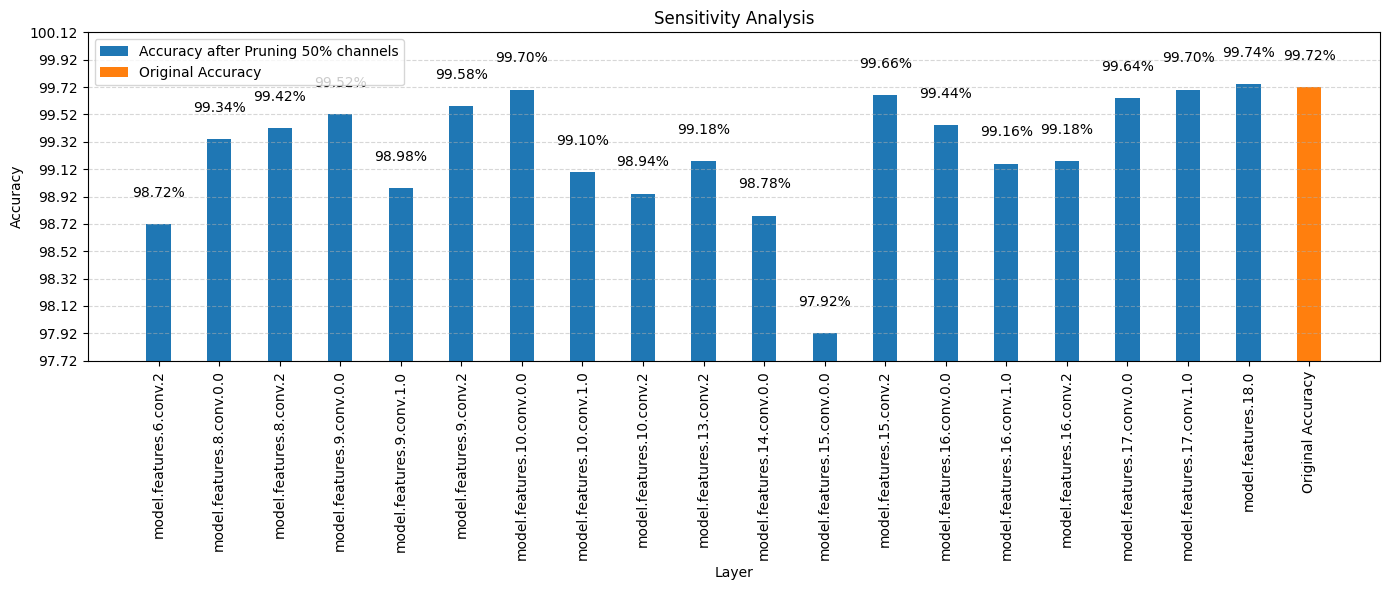

In [204]:
# Plot sensitivities
import matplotlib.pyplot as plt
layer_name = []
sensitivity = []
originalAcc = 99.72

for name, module in PrunningModel.named_modules():
    if isinstance(module, nn.Conv2d):
        if name in sensitivities:
            drop = 99.78 - sensitivities[name]
            if drop >= 2.0:
                continue

            layer_name.append(name)
            sensitivity.append(sensitivities[name])
print(layer_name)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
labels = layer_name + ["Original Accuracy"]
min_acc = min(sensitivity)
x = np.arange(len(labels))
x_layer = x[:-1]
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x_layer,
    sensitivity,
    width,
    label="Accuracy after Pruning 50% channels"
)

for i, acc in enumerate([sensitivities[n] for n in layer_name]):
    plt.text(
        x_layer[i],
        sensitivity[i] + 0.2,
        f"{acc:.2f}%",
        ha="center"
    )


plt.bar(
    x[-1],
    originalAcc,
    width,
    label="Original Accuracy"
)

# Original acc
plt.text(
    x[-1],
    originalAcc + 0.2,
    str(originalAcc)+"%",
    ha="center"
)

plt.ylabel("Accuracy")
plt.xlabel("Layer")
plt.title("Sensitivity Analysis")

plt.xticks(x, labels, rotation=90)
plt.ylim(min_acc - 0.2, originalAcc + 0.2)
plt.yticks(np.arange(min_acc - 0.2, originalAcc + 0.5, 0.2))        
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()

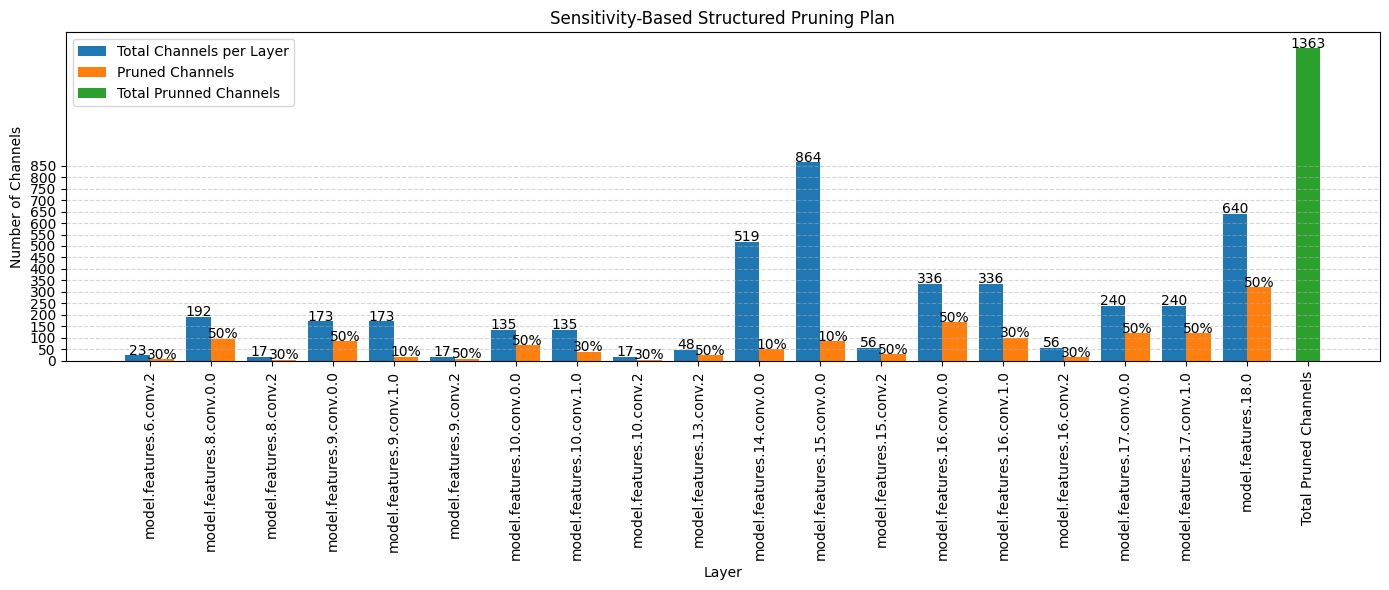

In [ ]:
# Plot Pruning Plan
layer_names = []
total_channels = []
pruned_channels = []

for name, module in PrunningModel.named_modules():

    if isinstance(module, nn.Conv2d):

        if name in pruning_plan:

            ratio = pruning_plan[name]

            # Skip layers not pruned
            if ratio == 0:
                continue

            out_ch = module.out_channels
            pruned_ch = int(out_ch * ratio)

            layer_names.append(name)
            total_channels.append(out_ch)
            pruned_channels.append(pruned_ch)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
max_channels = max(total_channels)
labels = layer_names + ["Total Pruned Channels"]
total_pruned_channels = sum(pruned_channels)
x = np.arange(len(labels))
x_layer = x[:-1]
width = 0.4

plt.figure(figsize=(14, 6))

for i, ratio in enumerate([pruning_plan[n] for n in layer_names]):
    plt.text(
        x_layer[i] + width/2,
        pruned_channels[i] + 2,
        f"{ratio*100:.0f}%",
        ha="center"
    )

for i, total in enumerate(total_channels):
    plt.text(
        x_layer[i] - width/2,      # center of total-channels bar
        total + 2,           # slightly above bar
        f"{total}",
        ha="center"
    )

plt.bar(
    x_layer - width/2,
    total_channels,
    width,
    label="Total Channels per Layer"
)

plt.bar(
    x_layer + width/2,
    pruned_channels,
    width,
    label="Pruned Channels"
)

plt.bar(
    x[-1],
    total_pruned_channels,
    width,
    label="Total Prunned Channels"
)

# Total pruned label
plt.text(
    x[-1],
    total_pruned_channels + 2,
    str(total_pruned_channels),
    ha="center"
)

plt.ylabel("Number of Channels")
plt.xlabel("Layer")
plt.title("Sensitivity-Based Structured Pruning Plan")

plt.xticks(x, labels, rotation=90)
plt.yticks(np.arange(0, max_channels + 5, 50))        # tick every 5 channels
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()